# Config A — Dynamic Programming
## Optimal Policy via Policy Iteration & Value Iteration

**Master in Data Science & Advanced Analytics — Reinforcement Learning**

---

This notebook computes the **optimal policy** for the ICU-Sepsis-v2 discrete MDP (716 states × 25 actions) using Dynamic Programming methods:

1. **Policy Iteration** — iterative policy evaluation + policy improvement until convergence
2. **Value Iteration** — direct Bellman optimality backup until convergence

In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath('..'))

In [2]:
!pip install icu-sepsis

In [3]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

from envs.env_setup import make_sepsis_env
from utils.evaluation import eval_agent, print_results
from utils.plotting import plot_comparison

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [4]:
def compute_expected_reward(P, R):
    """
    Convert the matrix of rewards R(s,a,s') into expected rewards R_expected(s,a) by summing over the next states s'.

    Args:
        P: tensor of transitions with shape (n_states, n_actions, n_states)
        R: tensor of rewards with shape (n_states, n_actions, n_states)

    Returns:
        R_expected: matrix with shape (n_states, n_actions)
    """
    # To each (s,a), we sum P(s,a,s') * R(s,a,s') over all s'
    R_expected = np.sum(P * R, axis=2)
    return R_expected

In [5]:
def compute_value_function(policy, P, R_expected, gamma=1.0):
    """
    Calculate the value function for a fixed policy (Policy Evaluation).

    Args:
        policy: array with shape (n_states,) — action to take in each state
        P: tensor of transitions with shape (n_states, n_actions, n_states)
        R_expected: matrix of expected rewards with shape (n_states, n_actions)
        gamma: discount factor

    Returns:
        value_table: array with shape (n_states,)
    """

    num_iterations = 10000

    # threshold to convergence
    threshold = 1e-6

    n_states = P.shape[0]

    # initialize value table with zeros
    value_table = np.zeros(n_states)

    #create a for loop to iteratively update the value table until convergence
    for i in range(num_iterations):

        updated_value_table = np.copy(value_table)

        for s in range(n_states):

            a = int(policy[s]) #select the action that the policy indicates for this state

            #calculate the value of the state using the Bellman equation: V(s) = sum_{s'} P(s'|s,a) * [R(s,a) + gamma * V(s')]
            value_table[s] = sum([
                P[s, a, s_next] * (R_expected[s, a] + gamma * updated_value_table[s_next])
                for s_next in range(n_states)
            ])

        #Check if the value table has converged by comparing the updated value table with the previous one. 
        #If the maximum absolute difference is <= to the threshold, we can stop the iteration.
        if np.max(np.abs(updated_value_table - value_table)) <= threshold:
            break

    return value_table

In [6]:
def extract_policy(value_table, P, R_expected, gamma=1.0):
    """
    Extract the optimal policy from the value function (Policy Improvement).

    Args:
        value_table: array with shape (n_states,) — current value function
        P: transition tensor with shape (n_states, n_actions, n_states)
        R_expected: expected rewards matrix with shape (n_states, n_actions)
        gamma: discount factor

    Returns:
        policy: array with shape (n_states,) — optimal action in each state
    """
    n_states, n_actions, _ = P.shape

    # initialize the policy with zeros
    policy = np.zeros(n_states)

    for s in range(n_states):

        # calculate the Q-value for each action in this state using the Bellman equation
        Q_values = [
            sum([
                P[s, a, s_next] * (R_expected[s, a] + gamma * value_table[s_next])
                for s_next in range(n_states)
            ])
            for a in range(n_actions)
        ]

        # choose the action with the highest Q-value (greedy step)
        policy[s] = np.argmax(np.array(Q_values))

    return policy

In [7]:
def policy_iteration(P, R, gamma=1.0):
    """
    Args:
        P: transition tensor with shape (n_states, n_actions, n_states)
        R: reward tensor with shape (n_states, n_actions, n_states)
        gamma: discount factor (1.0 by default — no temporal discount,
               equal to the ICU-Sepsis environment convention)

    Returns:
        policy: array with shape (n_states,) — optimal policy
        value_function: array with shape (n_states,) — optimal value function
        convergence_deltas: list with the maximum delta per iteration (for plotting convergence)
    """
    n_states = P.shape[0]

    # calculate the R_expected (s,a) from the R(s,a,s') of the environment
    R_expected = compute_expected_reward(P, R)

    policy = np.random.randint(0, P.shape[1], n_states)
    value_function = np.zeros(n_states)
    num_iterations = 1000 

    # list to store the convergence deltas
    convergence_deltas = []

    #create a for loop to iteratively perform policy evaluation and policy improvement until convergence
    for i in range(num_iterations):

        old_value = value_function.copy()
        # Policy Evaluation
        value_function = compute_value_function(policy, P, R_expected, gamma)

        # Policy Improvement
        new_policy = extract_policy(value_function, P, R_expected, gamma)

        delta = np.max(np.abs(old_value - value_function))
        convergence_deltas.append(delta)

        # if the policy does not change, we have converged and can stop the iteration
        if np.all(policy == new_policy):
            print(f'Policy Iteration converged after {i + 1} iterations!')
            break

        # otherwise, we update the policy
        policy = new_policy

    return policy.astype(int), value_function, convergence_deltas

In [8]:
def value_iteration(P, R, gamma=1.0):
    """
    Args:
        P: tensor of transitions with shape (n_states, n_actions, n_states)
        R: tensor of rewards with shape (n_states, n_actions, n_states)
        gamma: discount factor
    Returns:
        policy: array with shape (n_states,) — optimal policy
        value_function: array with shape (n_states,) — optimal value function
        convergence_deltas: list with the maximum delta per iteration
    """
    n_states, n_actions, _ = P.shape

    # calculate R_expected (s,a) from R(s,a,s') of the environment
    R_expected = compute_expected_reward(P, R)
    num_iterations = 10000
    threshold = 1e-6
    value_function = np.zeros(n_states) #initialize value function with zeros

    # create an empty list to store the convergence deltas for plotting
    convergence_deltas = []


    for i in range(num_iterations):
        
        updated_value_function = np.copy(value_function)
        
        for s in range(n_states):

            # calculate the Q-value for each action possible in this state using the Bellman equation
            Q_values = [
                sum([
                    P[s, a, s_next] * (R_expected[s, a] + gamma * updated_value_function[s_next])
                    for s_next in range(n_states)
                ])
                for a in range(n_actions)
            ]

            # actualizamos V(s) com o máximo dos Q-values (Bellman optimality)
            value_function[s] = np.max(Q_values)

        # calculamos o delta máximo entre iterações
        delta = np.max(np.abs(updated_value_function - value_function))
        convergence_deltas.append(delta)

        # if the delta is smaller than the threshold, we have converged and can stop the iteration
        if delta <= threshold:
            print(f'Value Iteration converged after {i + 1} iterations!')
            break

    # extract the optimal policy from the final value function
    policy = extract_policy(value_function, P, R_expected, gamma)

    return policy.astype(int), value_function, convergence_deltas

In [9]:
def get_policy(policy_array):
    """
    Args:
        policy_array: array with shape (n_states,)

    Returns:
        function that takes a state (int) and returns an action (int)
    """
    return lambda obs: int(policy_array[obs])

In [10]:
# Create the environment and extract the transition and reward matrices
env = make_sepsis_env()
raw = env.unwrapped
P = raw._tx_mat
R = raw._r_mat

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


In [11]:
# Random Baseline
random_policy = lambda obs: env.action_space.sample()
random_results = eval_agent(random_policy, make_sepsis_env, n_eval_episodes=1000, seed=42)
print_results("Random Baseline (Config A)", random_results)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
=== Random Baseline (Config A) ===
  Mean return  : 0.6282 ± 0.4485
  Survival rate: 73.4%
  Mean ep len  : 10.6


In [12]:
# Grid search 
import itertools
import pandas as pd

gammas = [0.9, 0.95, 0.99, 1.0]
grid_results = []

for gamma in gammas:
    p, v, _ = policy_iteration(P, R, gamma=gamma)
    res = eval_agent(get_policy(p), make_sepsis_env, n_eval_episodes=1000, seed=42)
    grid_results.append({
        "gamma": gamma,
        "algorithm": "Policy Iteration",
        "survival_rate": res["survival_rate"],
        "mean_return": res["mean_return"]
    })
    
    p, v, _ = value_iteration(P, R, gamma=gamma)
    res = eval_agent(get_policy(p), make_sepsis_env, n_eval_episodes=1000, seed=42)
    grid_results.append({
        "gamma": gamma,
        "algorithm": "Value Iteration",
        "survival_rate": res["survival_rate"],
        "mean_return": res["mean_return"]
    })

df = pd.DataFrame(grid_results)
print(df.to_string(index=False))

Policy Iteration converged after 4 iterations!
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Value Iteration converged after 57 iterations!
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Policy Iteration converged after 4 iterations!
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Value Iteration converged after 76 iterations!
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Policy Iteration converged after 4 iterations!
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Value Iteration converged after 103 iterations!
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Policy Iteration converged after 4 iterations!
make_sepsi

In [13]:
# Final results with gamma=1.0
policy_pi, V_pi, deltas_pi = policy_iteration(P, R, gamma=1.0)
policy_vi, V_vi, deltas_vi = value_iteration(P, R, gamma=1.0)

results_pi = eval_agent(get_policy(policy_pi), make_sepsis_env, n_eval_episodes=1000, seed=42)
results_vi = eval_agent(get_policy(policy_vi), make_sepsis_env, n_eval_episodes=1000, seed=42)

print_results("Policy Iteration", results_pi)
print_results("Value Iteration",  results_vi)

Policy Iteration converged after 4 iterations!
Value Iteration converged after 135 iterations!
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
=== Policy Iteration ===
  Mean return  : 0.7914 ± 0.3710
  Survival rate: 83.2%
  Mean ep len  : 10.6
=== Value Iteration ===
  Mean return  : 0.7914 ± 0.3710
  Survival rate: 83.2%
  Mean ep len  : 10.6


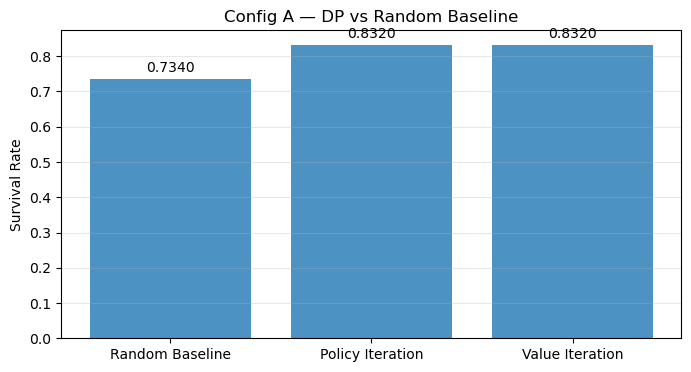

In [14]:
plot_comparison(
    {
        "Random Baseline": random_results,
        "Policy Iteration": results_pi,
        "Value Iteration":  results_vi,
    },
    metric="survival_rate",
    title="Config A — DP vs Random Baseline"
)
plt.show()

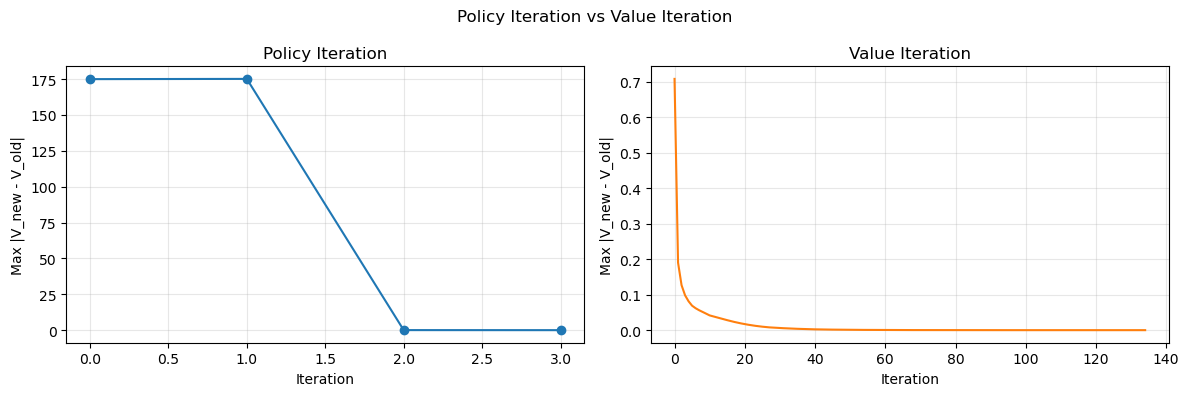

Policy iteration converged in 4 iterations.
Value iteration converged in 135 iterations.


In [15]:
# Convergence curves — Policy Iteration vs Value Iteration
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(deltas_pi, marker='o', color="tab:blue")
axes[0].set_title("Policy Iteration")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Max |V_new - V_old|")
axes[0].grid(alpha=0.3)

axes[1].plot(deltas_vi, color="tab:orange")
axes[1].set_title("Value Iteration")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Max |V_new - V_old|")
axes[1].grid(alpha=0.3)

plt.suptitle("Policy Iteration vs Value Iteration")
plt.tight_layout()
plt.show()
print(f"Policy iteration converged in {len(deltas_pi)} iterations.")
print(f"Value iteration converged in {len(deltas_vi)} iterations.")